# Inventory Optimization

This notebook converts demand forecasts into inventory management recommendations.

The analysis includes:

- Average demand
- Demand variability
- Lead-time demand
- Safety stock
- Reorder point
- Economic Order Quantity (EOQ)
- Inventory status
- Recommended order quantity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
BASE_DIR = Path.cwd().parent

results_dir = (
    BASE_DIR /
    "reports" /
    "model_results"
)

print("Inventory optimization environment ready.")

Inventory optimization environment ready.


In [3]:
forecast_path = (
    results_dir /
    "recursive_lightgbm_forecast.csv"
)

forecast = pd.read_csv(
    forecast_path,
    parse_dates=["date"]
)

print("Forecast loaded successfully.")
print("Shape:", forecast.shape)
print(forecast.head())

Forecast loaded successfully.
Shape: (1400, 4)
       item_id store_id       date  forecast_units
0  FOODS_3_090     CA_3 2016-04-25       85.326214
1  FOODS_3_090     CA_3 2016-04-26       79.701673
2  FOODS_3_090     CA_3 2016-04-27       80.318941
3  FOODS_3_090     CA_3 2016-04-28       85.978889
4  FOODS_3_090     CA_3 2016-04-29      115.257539


In [4]:
forecast_path = (
    results_dir /
    "recursive_lightgbm_forecast.csv"
)

forecast = pd.read_csv(
    forecast_path,
    parse_dates=["date"]
)

print("Forecast loaded successfully.")
print("Shape:", forecast.shape)
print(forecast.head())

Forecast loaded successfully.
Shape: (1400, 4)
       item_id store_id       date  forecast_units
0  FOODS_3_090     CA_3 2016-04-25       85.326214
1  FOODS_3_090     CA_3 2016-04-26       79.701673
2  FOODS_3_090     CA_3 2016-04-27       80.318941
3  FOODS_3_090     CA_3 2016-04-28       85.978889
4  FOODS_3_090     CA_3 2016-04-29      115.257539


In [5]:
inventory = (
    forecast
    .groupby(
        ["item_id", "store_id"]
    )["forecast_units"]
    .agg(
        forecast_28_day="sum",
        average_daily_forecast="mean",
        peak_daily_forecast="max"
    )
    .reset_index()
)

print("Inventory demand summary created.")
print(inventory.head())

Inventory demand summary created.
       item_id store_id  forecast_28_day  average_daily_forecast  \
0  FOODS_2_360     WI_2      1515.212910               54.114747   
1  FOODS_3_007     WI_2      1096.914048               39.175502   
2  FOODS_3_090     CA_1      1533.641416               54.772908   
3  FOODS_3_090     CA_2      1495.075233               53.395544   
4  FOODS_3_090     CA_3      3114.076578              111.217021   

   peak_daily_forecast  
0            71.353554  
1            56.248532  
2            75.808135  
3            74.134300  
4           153.254321  


In [9]:
inventory = (
    forecast
    .groupby(
        ["item_id", "store_id"]
    )["forecast_units"]
    .agg(
        forecast_28_day="sum",
        average_daily_forecast="mean",
        peak_daily_forecast="max"
    )
    .reset_index()
)

print("Inventory demand summary created.")
print(inventory.head())

Inventory demand summary created.
       item_id store_id  forecast_28_day  average_daily_forecast  \
0  FOODS_2_360     WI_2      1515.212910               54.114747   
1  FOODS_3_007     WI_2      1096.914048               39.175502   
2  FOODS_3_090     CA_1      1533.641416               54.772908   
3  FOODS_3_090     CA_2      1495.075233               53.395544   
4  FOODS_3_090     CA_3      3114.076578              111.217021   

   peak_daily_forecast  
0            71.353554  
1            56.248532  
2            75.808135  
3            74.134300  
4           153.254321  


In [11]:
# Step 48: Prepare historical demand statistics for inventory optimization

import pandas as pd
from pathlib import Path

# Project paths
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data" / "raw"

SALES_PATH = DATA_DIR / "sales_train_evaluation.csv"
CALENDAR_PATH = DATA_DIR / "calendar.csv"

print("Loading sales data...")
sales_inventory = pd.read_csv(SALES_PATH)

print("Sales shape:", sales_inventory.shape)

# Identify daily sales columns
day_columns_inventory = [
    column for column in sales_inventory.columns
    if column.startswith("d_")
]

print("Daily columns:", len(day_columns_inventory))

# Select the same top 50 item-store series used for LightGBM
sales_inventory["total_units"] = sales_inventory[day_columns_inventory].sum(axis=1)

top_series_inventory = sales_inventory.nlargest(
    50,
    "total_units"
).copy()

print("Top 50 series selected:", top_series_inventory.shape)

# Convert top 50 series from wide to long format
id_columns_inventory = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

top_series_long_inventory = top_series_inventory[
    id_columns_inventory + day_columns_inventory
].melt(
    id_vars=id_columns_inventory,
    var_name="d",
    value_name="units_sold"
)

print("Long-format data:", top_series_long_inventory.shape)

# Load calendar
calendar_inventory = pd.read_csv(CALENDAR_PATH)

calendar_inventory["date"] = pd.to_datetime(
    calendar_inventory["date"]
)

# Add dates
top_series_long_inventory = top_series_long_inventory.merge(
    calendar_inventory[["d", "date"]],
    on="d",
    how="left"
)

# Sort chronologically
top_series_long_inventory = top_series_long_inventory.sort_values(
    ["item_id", "store_id", "date"]
).reset_index(drop=True)

# Define the same 28-day validation period
validation_days = 28

max_date_inventory = top_series_long_inventory["date"].max()

validation_start_inventory = (
    max_date_inventory
    - pd.Timedelta(days=validation_days - 1)
)

print("Validation start:", validation_start_inventory)
print("Maximum date:", max_date_inventory)

# Keep only historical training period
historical_data = top_series_long_inventory[
    top_series_long_inventory["date"] < validation_start_inventory
].copy()

print("Historical data shape:", historical_data.shape)

# Calculate historical demand statistics
historical_stats = (
    historical_data
    .groupby(["item_id", "store_id"])["units_sold"]
    .agg(
        historical_mean_demand="mean",
        historical_std_demand="std",
        historical_max_demand="max"
    )
    .reset_index()
)

# Replace missing standard deviation with 0
historical_stats["historical_std_demand"] = (
    historical_stats["historical_std_demand"]
    .fillna(0)
)

print("\nHistorical statistics created successfully!")
print("Shape:", historical_stats.shape)

print("\nHistorical statistics:")
print(historical_stats.head(10))

Loading sales data...
Sales shape: (30490, 1947)
Daily columns: 1941


C:\Users\DELL-PC\AppData\Local\Temp\ipykernel_13932\3162378792.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sales_inventory["total_units"] = sales_inventory[day_columns_inventory].sum(axis=1)


Top 50 series selected: (50, 1948)
Long-format data: (97050, 7)
Validation start: 2016-04-25 00:00:00
Maximum date: 2016-05-22 00:00:00
Historical data shape: (95650, 8)

Historical statistics created successfully!
Shape: (50, 5)

Historical statistics:
       item_id store_id  historical_mean_demand  historical_std_demand  \
0  FOODS_2_360     WI_2               25.113957              33.508657   
1  FOODS_3_007     WI_2               27.192891              34.083424   
2  FOODS_3_090     CA_1               66.493988              57.862321   
3  FOODS_3_090     CA_2               29.361735              25.352470   
4  FOODS_3_090     CA_3              130.947203             108.611717   
5  FOODS_3_090     CA_4               27.320439              22.186007   
6  FOODS_3_090     TX_1               48.972295              46.050259   
7  FOODS_3_090     TX_2               62.465238              54.067378   
8  FOODS_3_090     TX_3               60.038683              48.101733   
9  FOO

In [12]:
# Step 49: Combine forecast results with historical statistics

inventory = inventory.merge(
    historical_stats,
    on=["item_id", "store_id"],
    how="left"
)

print("Forecast and historical demand combined successfully.")

print("\nInventory shape:", inventory.shape)

print("\nColumns:")
print(inventory.columns.tolist())

print("\nSample:")
print(inventory.head())

Forecast and historical demand combined successfully.

Inventory shape: (50, 8)

Columns:
['item_id', 'store_id', 'forecast_28_day', 'average_daily_forecast', 'peak_daily_forecast', 'historical_mean_demand', 'historical_std_demand', 'historical_max_demand']

Sample:
       item_id store_id  forecast_28_day  average_daily_forecast  \
0  FOODS_2_360     WI_2      1515.212910               54.114747   
1  FOODS_3_007     WI_2      1096.914048               39.175502   
2  FOODS_3_090     CA_1      1533.641416               54.772908   
3  FOODS_3_090     CA_2      1495.075233               53.395544   
4  FOODS_3_090     CA_3      3114.076578              111.217021   

   peak_daily_forecast  historical_mean_demand  historical_std_demand  \
0            71.353554               25.113957              33.508657   
1            56.248532               27.192891              34.083424   
2            75.808135               66.493988              57.862321   
3            74.134300          

In [13]:
# Step 50: Inventory optimization assumptions

lead_time_days = 7
service_level = 0.95
z_score = 1.645

ordering_cost = 50
holding_cost_per_unit = 2

print("Inventory assumptions:")
print("Lead time:", lead_time_days, "days")
print("Service level:", service_level)
print("Z-score:", z_score)
print("Ordering cost per order:", ordering_cost)
print("Holding cost per unit per year:", holding_cost_per_unit)

Inventory assumptions:
Lead time: 7 days
Service level: 0.95
Z-score: 1.645
Ordering cost per order: 50
Holding cost per unit per year: 2


In [14]:
# Step 51: Calculate expected demand during lead time

inventory["lead_time_demand"] = (
    inventory["average_daily_forecast"] * lead_time_days
)

print("Lead-time demand calculated.")

print(
    inventory[
        [
            "item_id",
            "store_id",
            "average_daily_forecast",
            "lead_time_demand"
        ]
    ].head(10)
)

Lead-time demand calculated.
       item_id store_id  average_daily_forecast  lead_time_demand
0  FOODS_2_360     WI_2               54.114747        378.803228
1  FOODS_3_007     WI_2               39.175502        274.228512
2  FOODS_3_090     CA_1               54.772908        383.410354
3  FOODS_3_090     CA_2               53.395544        373.768808
4  FOODS_3_090     CA_3              111.217021        778.519145
5  FOODS_3_090     CA_4               25.909337        181.365362
6  FOODS_3_090     TX_1               50.476445        353.335118
7  FOODS_3_090     TX_2               61.636869        431.458083
8  FOODS_3_090     TX_3               65.004026        455.028182
9  FOODS_3_090     WI_3               80.839350        565.875449


In [15]:
# Step 52: Calculate safety stock

inventory["safety_stock"] = (
    z_score
    * inventory["historical_std_demand"]
    * np.sqrt(lead_time_days)
)

# Prevent negative values
inventory["safety_stock"] = inventory["safety_stock"].clip(lower=0)

print("Safety stock calculated.")

print(
    inventory[
        [
            "item_id",
            "store_id",
            "historical_std_demand",
            "safety_stock"
        ]
    ].head(10)
)

Safety stock calculated.
       item_id store_id  historical_std_demand  safety_stock
0  FOODS_2_360     WI_2              33.508657    145.838418
1  FOODS_3_007     WI_2              34.083424    148.339956
2  FOODS_3_090     CA_1              57.862321    251.831918
3  FOODS_3_090     CA_2              25.352470    110.340564
4  FOODS_3_090     CA_3             108.611717    472.706530
5  FOODS_3_090     CA_4              22.186007     96.559292
6  FOODS_3_090     TX_1              46.050259    200.422741
7  FOODS_3_090     TX_2              54.067378    235.315335
8  FOODS_3_090     TX_3              48.101733    209.351293
9  FOODS_3_090     WI_3              55.096660    239.795038


In [16]:
# Step 53: Calculate reorder point

inventory["reorder_point"] = (
    inventory["lead_time_demand"]
    + inventory["safety_stock"]
)

print("Reorder point calculated.")

print(
    inventory[
        [
            "item_id",
            "store_id",
            "lead_time_demand",
            "safety_stock",
            "reorder_point"
        ]
    ].head(10)
)

Reorder point calculated.
       item_id store_id  lead_time_demand  safety_stock  reorder_point
0  FOODS_2_360     WI_2        378.803228    145.838418     524.641646
1  FOODS_3_007     WI_2        274.228512    148.339956     422.568468
2  FOODS_3_090     CA_1        383.410354    251.831918     635.242272
3  FOODS_3_090     CA_2        373.768808    110.340564     484.109373
4  FOODS_3_090     CA_3        778.519145    472.706530    1251.225674
5  FOODS_3_090     CA_4        181.365362     96.559292     277.924654
6  FOODS_3_090     TX_1        353.335118    200.422741     553.757858
7  FOODS_3_090     TX_2        431.458083    235.315335     666.773418
8  FOODS_3_090     TX_3        455.028182    209.351293     664.379476
9  FOODS_3_090     WI_3        565.875449    239.795038     805.670488


In [17]:
# Step 54: Calculate Economic Order Quantity (EOQ)

annual_demand = (
    inventory["average_daily_forecast"] * 365
)

inventory["eoq"] = np.sqrt(
    (
        2
        * annual_demand
        * ordering_cost
    )
    / holding_cost_per_unit
)

# Prevent values below 1
inventory["eoq"] = inventory["eoq"].clip(lower=1)

# Round to whole units
inventory["eoq"] = inventory["eoq"].round().astype(int)

print("EOQ calculated.")

print(
    inventory[
        [
            "item_id",
            "store_id",
            "average_daily_forecast",
            "eoq"
        ]
    ].head(10)
)

EOQ calculated.
       item_id store_id  average_daily_forecast   eoq
0  FOODS_2_360     WI_2               54.114747   994
1  FOODS_3_007     WI_2               39.175502   846
2  FOODS_3_090     CA_1               54.772908  1000
3  FOODS_3_090     CA_2               53.395544   987
4  FOODS_3_090     CA_3              111.217021  1425
5  FOODS_3_090     CA_4               25.909337   688
6  FOODS_3_090     TX_1               50.476445   960
7  FOODS_3_090     TX_2               61.636869  1061
8  FOODS_3_090     TX_3               65.004026  1089
9  FOODS_3_090     WI_3               80.839350  1215


In [18]:
# Step 55: Create inventory demand priority

low_threshold = inventory["forecast_28_day"].quantile(0.33)
high_threshold = inventory["forecast_28_day"].quantile(0.67)

inventory["inventory_priority"] = np.where(
    inventory["forecast_28_day"] >= high_threshold,
    "High Demand",
    np.where(
        inventory["forecast_28_day"] <= low_threshold,
        "Low Demand",
        "Medium Demand"
    )
)

print("Inventory priority created.")

print(
    inventory["inventory_priority"].value_counts()
)

Inventory priority created.
inventory_priority
High Demand      17
Low Demand       17
Medium Demand    16
Name: count, dtype: int64


In [19]:
# Step 56: Calculate recommended order quantity

inventory["recommended_order_quantity"] = (
    inventory["eoq"]
)

inventory["planning_action"] = np.where(
    inventory["forecast_28_day"]
    >= inventory["reorder_point"] * 4,
    "High Replenishment Need",
    "Standard Replenishment"
)

print("Recommended order quantities calculated.")

print(
    inventory[
        [
            "item_id",
            "store_id",
            "forecast_28_day",
            "reorder_point",
            "eoq",
            "recommended_order_quantity",
            "planning_action"
        ]
    ].head(10)
)

Recommended order quantities calculated.
       item_id store_id  forecast_28_day  reorder_point   eoq  \
0  FOODS_2_360     WI_2      1515.212910     524.641646   994   
1  FOODS_3_007     WI_2      1096.914048     422.568468   846   
2  FOODS_3_090     CA_1      1533.641416     635.242272  1000   
3  FOODS_3_090     CA_2      1495.075233     484.109373   987   
4  FOODS_3_090     CA_3      3114.076578    1251.225674  1425   
5  FOODS_3_090     CA_4       725.461446     277.924654   688   
6  FOODS_3_090     TX_1      1413.340471     553.757858   960   
7  FOODS_3_090     TX_2      1725.832332     666.773418  1061   
8  FOODS_3_090     TX_3      1820.112729     664.379476  1089   
9  FOODS_3_090     WI_3      2263.501796     805.670488  1215   

   recommended_order_quantity         planning_action  
0                         994  Standard Replenishment  
1                         846  Standard Replenishment  
2                        1000  Standard Replenishment  
3                  

In [20]:
# Step 57: Create final inventory optimization table

inventory_results = inventory[
    [
        "item_id",
        "store_id",
        "forecast_28_day",
        "average_daily_forecast",
        "peak_daily_forecast",
        "historical_mean_demand",
        "historical_std_demand",
        "historical_max_demand",
        "lead_time_demand",
        "safety_stock",
        "reorder_point",
        "eoq",
        "recommended_order_quantity",
        "inventory_priority",
        "planning_action"
    ]
].copy()

print("Final inventory table created.")

print("Shape:", inventory_results.shape)

print("\nColumns:")
print(inventory_results.columns.tolist())

print("\nFirst 10 records:")
print(inventory_results.head(10))

Final inventory table created.
Shape: (50, 15)

Columns:
['item_id', 'store_id', 'forecast_28_day', 'average_daily_forecast', 'peak_daily_forecast', 'historical_mean_demand', 'historical_std_demand', 'historical_max_demand', 'lead_time_demand', 'safety_stock', 'reorder_point', 'eoq', 'recommended_order_quantity', 'inventory_priority', 'planning_action']

First 10 records:
       item_id store_id  forecast_28_day  average_daily_forecast  \
0  FOODS_2_360     WI_2      1515.212910               54.114747   
1  FOODS_3_007     WI_2      1096.914048               39.175502   
2  FOODS_3_090     CA_1      1533.641416               54.772908   
3  FOODS_3_090     CA_2      1495.075233               53.395544   
4  FOODS_3_090     CA_3      3114.076578              111.217021   
5  FOODS_3_090     CA_4       725.461446               25.909337   
6  FOODS_3_090     TX_1      1413.340471               50.476445   
7  FOODS_3_090     TX_2      1725.832332               61.636869   
8  FOODS_3_09

In [21]:
# Step 58: Validate inventory optimization results

print("Checking missing values...")

print(
    inventory_results.isnull().sum()
)

print("\nChecking negative numeric values...")

numeric_columns = inventory_results.select_dtypes(
    include="number"
).columns

negative_values = (
    inventory_results[numeric_columns] < 0
).sum()

print(negative_values)

print("\nChecking duplicate item-store combinations...")

duplicates = inventory_results.duplicated(
    subset=["item_id", "store_id"]
).sum()

print("Duplicates:", duplicates)

print("\nValidation complete.")

Checking missing values...
item_id                       0
store_id                      0
forecast_28_day               0
average_daily_forecast        0
peak_daily_forecast           0
historical_mean_demand        0
historical_std_demand         0
historical_max_demand         0
lead_time_demand              0
safety_stock                  0
reorder_point                 0
eoq                           0
recommended_order_quantity    0
inventory_priority            0
planning_action               0
dtype: int64

Checking negative numeric values...
forecast_28_day               0
average_daily_forecast        0
peak_daily_forecast           0
historical_mean_demand        0
historical_std_demand         0
historical_max_demand         0
lead_time_demand              0
safety_stock                  0
reorder_point                 0
eoq                           0
recommended_order_quantity    0
dtype: int64

Checking duplicate item-store combinations...
Duplicates: 0

Validation compl

In [22]:
# Step 59: Save inventory optimization results

from pathlib import Path

RESULTS_DIR = Path.cwd().parent / "reports" / "model_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

inventory_results_path = (
    RESULTS_DIR / "inventory_optimization_results.csv"
)

inventory_results.to_csv(
    inventory_results_path,
    index=False
)

print("Inventory optimization results saved successfully!")
print(inventory_results_path)

Inventory optimization results saved successfully!
c:\Users\DELL-PC\Desktop\retail-demand-forecasting\reports\model_results\inventory_optimization_results.csv


In [23]:
# Step 60: Top 10 item-store combinations by forecast demand

top_10_inventory = inventory_results.sort_values(
    "forecast_28_day",
    ascending=False
).head(10)

print("Top 10 item-store combinations by 28-day forecast:")

print(
    top_10_inventory[
        [
            "item_id",
            "store_id",
            "forecast_28_day",
            "average_daily_forecast",
            "reorder_point",
            "safety_stock",
            "eoq",
            "inventory_priority"
        ]
    ].to_string(index=False)
)

Top 10 item-store combinations by 28-day forecast:
    item_id store_id  forecast_28_day  average_daily_forecast  reorder_point  safety_stock  eoq inventory_priority
FOODS_3_090     CA_3      3114.076578              111.217021    1251.225674    472.706530 1425        High Demand
FOODS_3_090     WI_3      2263.501796               80.839350     805.670488    239.795038 1215        High Demand
FOODS_3_586     TX_2      2051.961619               73.284344     647.385754    134.395349 1156        High Demand
FOODS_3_120     CA_3      1936.090357               69.146084     682.503423    198.480833 1123        High Demand
FOODS_3_586     CA_3      1911.845351               68.280191     555.354270     77.392932 1116        High Demand
FOODS_3_090     TX_3      1820.112729               65.004026     664.379476    209.351293 1089        High Demand
FOODS_3_090     TX_2      1725.832332               61.636869     666.773418    235.315335 1061        High Demand
FOODS_3_586     TX_3      162

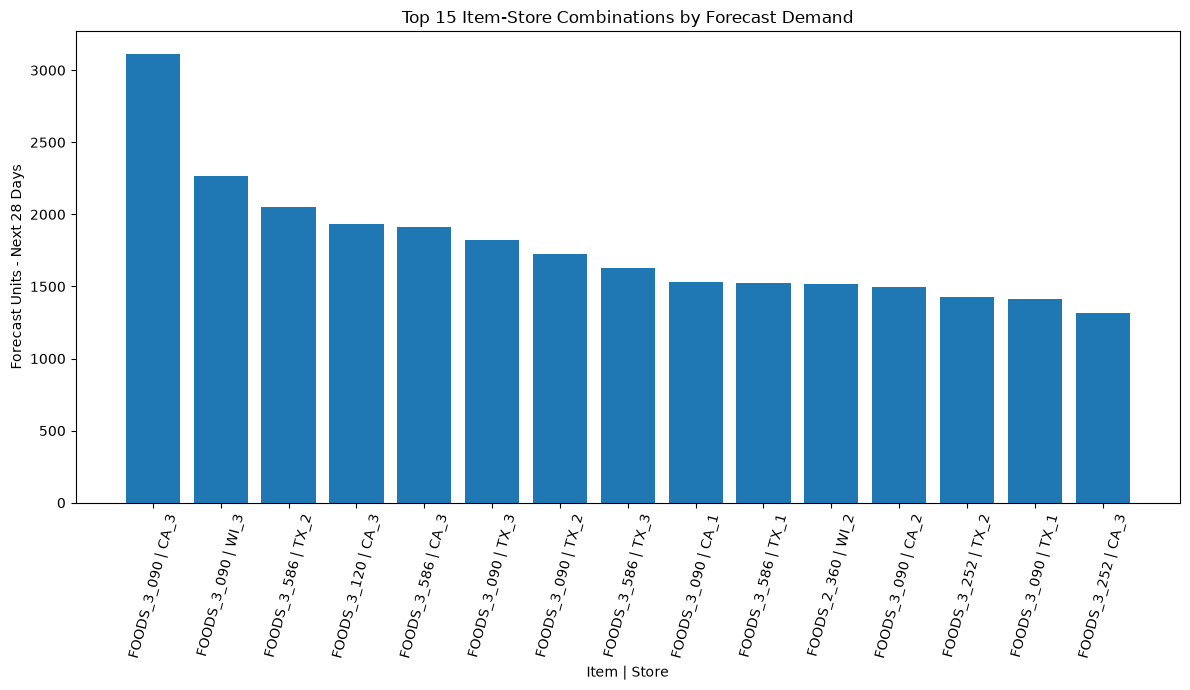

In [24]:
import matplotlib.pyplot as plt

top_15 = inventory_results.sort_values(
    "forecast_28_day",
    ascending=False
).head(15)

labels = (
    top_15["item_id"].astype(str)
    + " | "
    + top_15["store_id"].astype(str)
)

plt.figure(figsize=(12, 7))

plt.bar(
    labels,
    top_15["forecast_28_day"]
)

plt.xticks(rotation=75)

plt.xlabel("Item | Store")
plt.ylabel("Forecast Units - Next 28 Days")
plt.title("Top 15 Item-Store Combinations by Forecast Demand")

plt.tight_layout()
plt.show()